# Notebook 05: Generación de Explicaciones en Lenguaje Natural con LLM y Evaluación

> Proyecto Final — Inteligencia Artificial · Universidad EAFIT 2026-1

Este notebook implementa el acoplamiento final del pipeline de IA. Tomamos las predicciones cuantitativas del clasificador **XGBoost** (Notebook 03) y los valores locales **SHAP** (Notebook 04) para alimentar un **Modelo de Lenguaje (LLM — Llama 3.1 vía Groq)**.

El LLM actúa como un **analista senior de Venture Capital (VC)**, traduciendo los pesos matemáticos de SHAP a narrativas de negocio accionables, claras y profesionales en español.

### Estructura del notebook
1. Importación de librerías y carga de artefactos
2. Selección de casos representativos
3. Prompt Engineering — iteración de versiones (v1 → v3)
4. Generación de explicaciones para los 3 casos
5. Evaluación cuantitativa automática
6. Evaluación cualitativa — rúbrica analítica
7. Conclusiones y artefactos exportados

---

## 1. Importación de Librerías y Carga de Artefactos

Cargamos los datos procesados, predicciones y SHAP values locales generados en el Notebook 04.

In [ ]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown

# Agregar la carpeta raíz al path para importar src/
sys.path.append(os.path.abspath('../'))
from src.llm.explainer import StartupExplainer, GroqConnectionError
from src.llm.evaluation import (
    evaluate_explanation,
    composite_score,
    select_representative_indices,
    top_shap_features,
)

# Rutas
PROCESSED = '../data/processed'  # Para LEER datos
DOCS_DIR  = '../docs'  # Para GUARDAR explicaciones, gráficas y reportes
OUT_DIR   = f'{DOCS_DIR}/llm_explanations'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

# Cargar artefactos
X_test      = pd.read_csv(f'{PROCESSED}/X_test.csv')
y_test      = pd.read_csv(f'{PROCESSED}/y_test.csv').squeeze()
predictions = pd.read_csv(f'{PROCESSED}/predictions_test.csv')
shap_df     = pd.read_csv(f'{PROCESSED}/shap_values_test.csv')

assert len(X_test) == len(predictions) == len(shap_df), "Longitudes inconsistentes"
y_proba = predictions['y_proba'].values

print(f'Test cases   : {X_test.shape[0]} muestras, {X_test.shape[1]} features')
print(f'Predicciones : {predictions.shape[0]} filas')
print(f'SHAP values  : {shap_df.shape[0]} filas, {shap_df.shape[1]} columnas')
predictions.head()

Test cases   : 185 muestras, 31 features
Predicciones : 185 filas
SHAP values  : 185 filas, 31 columnas


,y_true,y_pred,y_proba
0,1,1,0.912943
1,1,1,0.916680
2,1,1,0.747238
3,0,0,0.077349
4,1,1,0.970808


## 2. Selección de Casos Representativos

Para cubrir el espectro completo de predicciones del modelo seleccionamos tres casos:

| Caso | Criterio | Objetivo |
|------|----------|----------|
| **Éxito — alta confianza** | Máxima `y_proba` con `y_true = 1` | Verificar que el LLM explica correctamente fortalezas |
| **Cierre — alta confianza** | Mínima `y_proba` con `y_true = 0` | Verificar coherencia de alertas y riesgos |
| **Borderline** | `y_proba` más cercana a 0.5 | El caso más difícil: ambigüedad real |

In [ ]:
# Selección de índices
idx_exitoso   = predictions[predictions['y_true'] == 1].sort_values('y_proba', ascending=False).index[0]
idx_fallido   = predictions[predictions['y_true'] == 0].sort_values('y_proba', ascending=True).index[0]
predictions['dist_from_border'] = (predictions['y_proba'] - 0.5).abs()
idx_borderline = predictions.sort_values('dist_from_border').index[0]

CASOS = {
    'exito_alta_confianza': {
        'titulo'     : 'Éxito — Alta Confianza',
        'descripcion': 'Máxima probabilidad de adquisición en el test set',
        'index'      : idx_exitoso,
        'y_proba'    : float(predictions.loc[idx_exitoso, 'y_proba']),
        'y_true'     : int(y_test.iloc[idx_exitoso]),
        'y_pred'     : int(predictions.loc[idx_exitoso, 'y_pred']),
    },
    'cierre_alta_confianza': {
        'titulo'     : 'Cierre — Alta Confianza',
        'descripcion': 'Mínima probabilidad de éxito (alta confianza en cierre)',
        'index'      : idx_fallido,
        'y_proba'    : float(predictions.loc[idx_fallido, 'y_proba']),
        'y_true'     : int(y_test.iloc[idx_fallido]),
        'y_pred'     : int(predictions.loc[idx_fallido, 'y_pred']),
    },
    'borderline': {
        'titulo'     : 'Borderline',
        'descripcion': 'Probabilidad más cercana a 0.5 (caso ambiguo)',
        'index'      : idx_borderline,
        'y_proba'    : float(predictions.loc[idx_borderline, 'y_proba']),
        'y_true'     : int(y_test.iloc[idx_borderline]),
        'y_pred'     : int(predictions.loc[idx_borderline, 'y_pred']),
    },
}

# Guardar casos representativos
# Convertir int64 a int para JSON serialization
for caso_info in CASOS.values():
    caso_info['index'] = int(caso_info['index'])

with open(f'{DOCS_DIR}/representative_cases.json', 'w', encoding='utf-8') as f:
    json.dump(CASOS, f, indent=2, ensure_ascii=False)

# Mostrar resumen
df_casos = pd.DataFrame([
    {'Caso': v['titulo'], 'Índice': v['index'],
     'y_proba': f"{v['y_proba']:.4f}", 'y_true': v['y_true'], 'y_pred': v['y_pred']}
    for v in CASOS.values()
])
display(df_casos)

,Caso,Índice,y_proba,y_true,y_pred
0,Éxito — Alta Confianza,88,0.9966,1,1
1,Cierre — Alta Confianza,86,0.0011,0,0
2,Borderline,133,0.5075,1,1


## 3. Inicialización del Explainer (Groq — Llama 3.1)

Verificamos la conexión con la API de Groq antes de generar explicaciones. Asegúrate de tener `GROQ_API_KEY` configurada en tu archivo `.env` en la raíz del proyecto.

In [ ]:
explainer = StartupExplainer(model_name='llama-3.1-8b-instant')

try:
    msg = explainer.validate_connection()
    print(msg)
except GroqConnectionError as e:
    raise RuntimeError(
        'Configura GROQ_API_KEY en .env antes de ejecutar este notebook.\n'
        'Instrucciones en README.md sección 4.'
    ) from e

Conexión OK — modelo=llama-3.1-8b-instant, respuesta='¿En qué puedo ayudarte?'


## 4. Prompt Engineering — Iteración de Versiones

Implementamos tres versiones del prompt para medir el impacto de cada mejora sobre la calidad de la explicación generada:

| Versión | Enfoque | Temperature | Cambio principal |
|---------|---------|-------------|------------------|
| **v1_base** | Prompt estándar | 0.4 | Línea base con instrucciones generales |
| **v2_mejorado** | Fidelidad SHAP explícita | 0.3 | Instrucción de alineación numérica |
| **v3_optimizado** | Rigidez + verificación | 0.2 | Checklist interno + veredicto forzado |

> **Hipótesis:** A menor temperatura y mayor especificidad del prompt, mayor fidelidad al veredicto y a los valores SHAP — a costa de cierta creatividad narrativa.

In [ ]:
# ── Definición de las 3 versiones de prompt ──────────────────────────────────

SYSTEM_BASE = (
    "Eres un analista experto en Venture Capital y científico de datos. "
    "Tu especialidad es evaluar startups tecnológicas e interpretar modelos predictivos. "
    "Tu tono debe ser analítico, profesional y comprensible para inversionistas financieros."
)

SYSTEM_V2 = SYSTEM_BASE + (
    " IMPORTANTE: debes ser fiel a los valores SHAP recibidos. "
    "Si un factor tiene SHAP positivo, descríbelo como fortaleza. "
    "Si tiene SHAP negativo, descríbelo como alerta. No inviertas la dirección bajo ningún motivo."
)

SYSTEM_V3 = SYSTEM_V2 + (
    " Antes de redactar, verifica internamente: "
    "(1) ¿El veredicto de tu informe coincide con la probabilidad dada? "
    "(2) ¿Mencionas explícitamente cada factor SHAP listado? "
    "(3) ¿Tus recomendaciones apuntan directamente a los factores negativos? "
    "Solo redacta el informe si las tres respuestas son SÍ."
)


def build_user_prompt_v1(pos_text: str, neg_text: str, prob_pct: float, verdict: str) -> str:
    """v1_base — instrucciones generales."""
    return f"""Has recibido una predicción de un modelo XGBoost entrenado sobre datos históricos de Crunchbase.
Tu tarea es explicar esta predicción usando los valores SHAP y redactar un informe ejecutivo en español.

### Predicción del Modelo:
- **Veredicto:** {verdict}
- **Probabilidad de Éxito:** {prob_pct:.2f}%

### Factores Positivos (SHAP > 0):
{pos_text}

### Factores de Riesgo (SHAP < 0):
{neg_text}

Redacta un informe de 4 secciones en Markdown:
1. **Resumen Ejecutivo**
2. **Fortalezas del Ecosistema y Operación**
3. **Puntos Críticos de Alerta**
4. **Recomendaciones Estratégicas del VC** (2 a 3 acciones concretas)""".strip()


def build_user_prompt_v2(pos_text: str, neg_text: str, prob_pct: float, verdict: str) -> str:
    """v2_mejorado — énfasis en fidelidad SHAP y coherencia numérica."""
    return f"""Has recibido una predicción de un modelo XGBoost entrenado sobre datos históricos de Crunchbase.
Tu tarea es explicar esta predicción usando valores SHAP locales y redactar un informe ejecutivo estructurado en español.

### Predicción del Modelo:
- **Veredicto Final:** {verdict}
- **Probabilidad de Éxito Estimada:** {prob_pct:.2f}%

### Factores Positivos de Mayor Peso — SHAP > 0 (menciónalos TODOS):
{pos_text}

### Factores de Riesgo de Mayor Peso — SHAP < 0 (menciónalos TODOS):
{neg_text}

**Instrucción crítica:** El tono y veredicto del informe DEBEN ser coherentes con la probabilidad {prob_pct:.2f}%.
Si la probabilidad es ≥ 50%, el tono es optimista pero realista. Si es < 50%, el tono es cauteloso y de alerta.

Redacta un informe ejecutivo en Markdown con exactamente 4 secciones:
1. **Resumen Ejecutivo** — síntesis de la predicción y nivel de confianza
2. **Fortalezas del Ecosistema y Operación** — analiza cada factor SHAP positivo
3. **Puntos Críticos de Alerta** — analiza cada factor SHAP negativo
4. **Recomendaciones Estratégicas del VC** — 2 a 3 acciones concretas y accionables""".strip()


def build_user_prompt_v3(pos_text: str, neg_text: str, prob_pct: float, verdict: str) -> str:
    """v3_optimizado — máxima rigidez, verificación explícita y recomendaciones ancladas en SHAP."""
    return f"""Has recibido una predicción de un modelo XGBoost entrenado sobre datos históricos de Crunchbase.
Debes generar un informe ejecutivo de Venture Capital (VC) basado estrictamente en los valores SHAP.

### Datos de la Predicción:
- **Veredicto Final del Modelo:** {verdict}
- **Probabilidad de Éxito Estimada:** {prob_pct:.2f}%

### Factores que AUMENTAN la probabilidad de éxito — SHAP positivos (cítalos todos con su impacto):
{pos_text}

### Factores que REDUCEN la probabilidad de éxito — SHAP negativos (cítalos todos con su impacto):
{neg_text}

**Reglas estrictas de redacción:**
- El veredicto de tu informe DEBE coincidir con '{verdict}' (probabilidad {prob_pct:.2f}%)
- Cita EXPLÍCITAMENTE cada factor SHAP listado arriba en la sección correspondiente
- Las recomendaciones deben abordar DIRECTAMENTE los factores negativos listados
- No introduzcas factores externos que no estén en los datos SHAP
- Usa lenguaje de negocio claro, evita jerga estadística en exceso

Redacta el informe en Markdown con exactamente estas 4 secciones:
1. **Resumen Ejecutivo** — veredicto claro, probabilidad y nivel de confianza
2. **Fortalezas del Ecosistema y Operación** — análisis de cada SHAP positivo con razonamiento de negocio
3. **Puntos Críticos de Alerta** — análisis de cada SHAP negativo con implicaciones reales
4. **Recomendaciones Estratégicas del VC** — 3 acciones concretas, cada una ligada a un factor negativo""".strip()


PROMPT_VERSIONS = {
    'v1_base'       : {'system': SYSTEM_BASE, 'user_fn': build_user_prompt_v1, 'temperature': 0.4},
    'v2_mejorado'   : {'system': SYSTEM_V2,   'user_fn': build_user_prompt_v2, 'temperature': 0.3},
    'v3_optimizado' : {'system': SYSTEM_V3,   'user_fn': build_user_prompt_v3, 'temperature': 0.2},
}

print('Versiones de prompt definidas:')
for k, v in PROMPT_VERSIONS.items():
    print(f'  {k:20s} — temperature={v["temperature"]}, system_len={len(v["system"])} chars')

Versiones de prompt definidas:
  v1_base              — temperature=0.4, system_len=238 chars
  v2_mejorado          — temperature=0.3, system_len=450 chars
  v3_optimizado        — temperature=0.2, system_len=742 chars


## 5. Generación de Explicaciones para los 3 Casos

Para cada caso representativo generamos una explicación con cada versión del prompt, guardamos el resultado en Markdown y calculamos las métricas automáticas.

In [ ]:
def get_pos_neg_text(idx: int) -> tuple[str, str]:
    """Extrae los top factores SHAP positivos y negativos para un índice dado."""
    shap_dict = shap_df.iloc[idx].to_dict()
    pos_items = [(f, v) for f, v in shap_dict.items() if v > 0.05]
    neg_items = [(f, v) for f, v in shap_dict.items() if v < -0.05]
    pos_items = sorted(pos_items, key=lambda x: x[1], reverse=True)[:5]
    neg_items = sorted(neg_items, key=lambda x: x[1])[:5]

    def fmt(items, direction):
        if not items:
            return '- Ninguno con impacto significativo.'
        lines = []
        for feat, val in items:
            label = StartupExplainer.readable_feature_name(feat)
            raw   = X_test.iloc[idx][feat]
            fval  = StartupExplainer.format_feature_value(feat, raw)
            sign  = f'+{val:.3f}' if val > 0 else f'{val:.3f}'
            lines.append(f'- **{label}** (Valor: {fval}): SHAP = {sign}')
        return '\n'.join(lines)

    return fmt(pos_items, 'pos'), fmt(neg_items, 'neg')


# ── Bucle principal ───────────────────────────────────────────────────────────
all_results = []

for caso_key, caso_info in CASOS.items():
    idx     = caso_info['index']
    y_p     = caso_info['y_proba']
    titulo  = caso_info['titulo']
    verdict = 'ÉXITO / ADQUISICIÓN' if y_p >= 0.5 else 'CIERRE / FRACASO'
    prob_pct = y_p * 100

    features_dict  = X_test.iloc[idx].to_dict()
    shap_dict      = shap_df.iloc[idx].to_dict()
    pos_text, neg_text = get_pos_neg_text(idx)

    display(Markdown(f'---\n### Caso: {titulo} | idx={idx} | p={y_p:.2%}'))

    caso_result = {
        'caso'    : caso_key,
        'titulo'  : titulo,
        'index'   : idx,
        'y_proba' : y_p,
        'versions': {},
    }

    for ver_key, ver_cfg in PROMPT_VERSIONS.items():
        system_prompt = ver_cfg['system']
        user_prompt   = ver_cfg['user_fn'](pos_text, neg_text, prob_pct, verdict)
        temperature   = ver_cfg['temperature']

        # Llamada al LLM con reintentos para evitar Rate Limit (429) de Groq
        import time
        max_retries = 5
        retry_delay = 5
        explanation = ""
        for attempt in range(max_retries):
            try:
                response = explainer.client.chat.completions.create(
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user",   "content": user_prompt},
                    ],
                    model=explainer.model_name,
                    temperature=temperature,
                )
                explanation = response.choices[0].message.content or ""
                break
            except Exception as exc:
                if "429" in str(exc) and attempt < max_retries - 1:
                    print(f"    [Rate Limit 429] Reintentando en {retry_delay}s... (Intento {attempt+1}/{max_retries})")
                    time.sleep(retry_delay)
                    retry_delay *= 2
                else:
                    explanation = f"[ERROR al generar explicación: {exc}]"
                    break
        time.sleep(2)  # Pausa mínima de cortesía entre llamadas consecutivas exitosas

        # Métricas automáticas
        metrics = evaluate_explanation(explanation, features_dict, shap_dict, y_p)
        metrics['composite'] = composite_score(metrics)

        # Guardar .md
        ver_dir = f'{OUT_DIR}/{ver_key}'
        os.makedirs(ver_dir, exist_ok=True)
        out_path = f'{ver_dir}/{caso_key}.md'
        with open(out_path, 'w', encoding='utf-8') as f:
            f.write(f'# {titulo} — {ver_key}\n\n')
            f.write(f'**Probabilidad de éxito:** {y_p:.4f} ({prob_pct:.2f}%)\n\n')
            f.write(explanation)

        caso_result['versions'][ver_key] = {
            'system_prompt': system_prompt,
            'user_prompt'  : user_prompt,
            'explanation'  : explanation,
            'metrics'      : metrics,
            'output_path'  : out_path,
        }

        # Print métricas al vuelo
        print(f'  [{ver_key:15s}]  composite={metrics["composite"]:.2f}  '
              f'verdict={metrics["verdict_alignment"]:.2f}  '
              f'shap_rate={metrics["shap_mention_rate"]:.2f}  '
              f'action={metrics["actionability"]:.2f}  '
              f'struct={metrics["structure"]:.2f}')

    all_results.append(caso_result)

print('\n Todas las explicaciones generadas y guardadas.')


---
### Caso: Éxito — Alta Confianza | idx=88 | p=99.66%

  [v1_base        ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00
  [v2_mejorado    ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00
  [v3_optimizado  ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00


---
### Caso: Cierre — Alta Confianza | idx=86 | p=0.11%

  [v1_base        ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00
  [v2_mejorado    ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00
  [v3_optimizado  ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00


---
### Caso: Borderline | idx=133 | p=50.75%

  [v1_base        ]  composite=0.96  verdict=1.00  shap_rate=0.90  action=1.00  struct=1.00
  [v2_mejorado    ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00
  [v3_optimizado  ]  composite=1.00  verdict=1.00  shap_rate=1.00  action=1.00  struct=1.00

 Todas las explicaciones generadas y guardadas.


### 5.1 Visualización de las explicaciones generadas

Mostramos la explicación de la versión ganadora (`v3_optimizado`) para cada caso.

In [ ]:
BEST_VERSION = 'v3_optimizado'

for result in all_results:
    display(Markdown(f'---\n## {result["titulo"]} | p={result["y_proba"]:.2%}'))
    display(Markdown(result['versions'][BEST_VERSION]['explanation']))

---
## Éxito — Alta Confianza | p=99.66%

**Informe Ejecutivo de Venture Capital**

### 1. **Resumen Ejecutivo**
**Veredicto:** ÉXITO / ADQUISICIÓN
**Probabilidad de Éxito Estimada:** 99.66%
**Nivel de Confianza:** Alto

Basado en la predicción del modelo XGBoost entrenado en datos históricos de Crunchbase, se estima una alta probabilidad de éxito para la startup en cuestión. El veredicto de éxitos es claro y respaldado por una probabilidad de 99.66%, lo que indica un alto nivel de confianza en la predicción.

### 2. **Fortalezas del Ecosistema y Operación**
Las siguientes fortalezas del ecosistema y operación de la startup han contribuido significativamente a la alta probabilidad de éxito:

* **Edad al alcanzar último hito (años)**: Con una edad de 1.64 años, la startup ha logrado alcanzar un hito importante en un plazo relativamente corto, lo que sugiere una alta capacidad de crecimiento y adaptabilidad. (SHAP = +1.322)
* **Número de relaciones/contactos clave de los fundadores**: Con 15 contactos clave, los fundadores de la startup han establecido una sólida red de relaciones que pueden ser beneficiosas para el crecimiento y el desarrollo de la empresa. (SHAP = +0.880)
* **Promedio de participantes por ronda**: Con un promedio de 1.15 participantes por ronda, la startup ha logrado atraer inversores comprometidos y con experiencia, lo que sugiere una alta calidad de la financiación. (SHAP = +0.799)
* **Sector: Videojuegos/Games & Video**: La pertenencia a un sector en crecimiento y con alta demanda de contenido, como los videojuegos, sugiere que la startup tiene un mercado amplio y con oportunidades de crecimiento. (SHAP = +0.766)
* **Completó Ronda D**: La capacidad de la startup para completar una ronda de financiación de serie D sugiere que la empresa ha logrado alcanzar un nivel de madurez y crecimiento significativo, lo que es un indicador positivo de su viabilidad. (SHAP = +0.511)

### 3. **Puntos Críticos de Alerta**
A continuación, se presentan los puntos críticos de alerta que pueden afectar la probabilidad de éxito de la startup:

* **Sector: Otras Industrias**: La falta de pertenencia a un sector en crecimiento y con alta demanda de contenido puede limitar las oportunidades de crecimiento y la viabilidad de la startup. (SHAP = -0.235)
* **Sector: Web**: La falta de pertenencia a un sector en crecimiento y con alta demanda de contenido puede limitar las oportunidades de crecimiento y la viabilidad de la startup. (SHAP = -0.144)
* **Edad al recibir último financiamiento (años)**: Con una edad de 0.15 años, la startup ha recibido financiamiento en un plazo relativamente corto, lo que sugiere que la empresa puede estar en una etapa de crecimiento acelerado y con alta demanda de recursos. (SHAP = -0.138)
* **Ubicación en Massachusetts (MA)**: La falta de ubicación en Massachusetts, un estado con una alta concentración de empresas tecnológicas y de capital riesgo, puede limitar las oportunidades de crecimiento y la accesibilidad a recursos y redes de contactos. (SHAP = -0.094)
* **Financiada por inversionistas Ángeles**: La falta de financiamiento por parte de inversionistas ángeles puede limitar la accesibilidad a recursos y redes de contactos, lo que puede afectar la creación de valor y la viabilidad de la startup. (SHAP = -0.091)

### 4. **Recomendaciones Estratégicas del VC**
Basado en los puntos críticos de alerta identificados, se presentan las siguientes recomendaciones estratégicas para el VC:

1. **Invertir en la creación de una red de contactos y relaciones en el sector de videojuegos**: La startup puede beneficiarse de invertir en la creación de una red de contactos y relaciones en el sector de videojuegos, lo que puede ayudar a aumentar la visibilidad y la accesibilidad a oportunidades de crecimiento.
2. **Considerar la ubicación en Massachusetts**: La startup puede considerar la ubicación en Massachusetts, un estado con una alta concentración de empresas tecnológicas y de capital riesgo, lo que puede ayudar a aumentar la accesibilidad a recursos y redes de contactos.
3. **Invertir en la creación de un equipo de marketing y ventas**: La startup puede beneficiarse de invertir en la creación de un equipo de marketing y ventas, lo que puede ayudar a aumentar la visibilidad y la accesibilidad a oportunidades de crecimiento en el mercado de videojuegos.

---
## Cierre — Alta Confianza | p=0.11%

**Informe Ejecutivo de Venture Capital**
=====================================

### Resumen Ejecutivo
-------------------

Basado en la predicción del modelo XGBoost, nuestro veredicto es CIERRE / FRACASO con una probabilidad estimada del 0.11%. Este resultado sugiere que la startup en cuestión enfrenta un alto riesgo de fracaso.

### Fortalezas del Ecosistema y Operación
--------------------------------------

Aunque el resultado general es negativo, hay algunas fortalezas en el ecosistema y la operación de la startup que podrían ser aprovechadas:

* **Sector: Otras Industrias**: La ubicación en el sector de "Otras Industrias" es una fortaleza con un impacto SHAP de +0.429. Esto sugiere que la startup tiene una ventaja competitiva en este nicho específico.
* **Completó Ronda B**: La capacidad de completar una ronda B es una señal de confianza en la startup, con un impacto SHAP de +0.296. Esto indica que la startup ha demostrado su capacidad para atraer inversión y crecer.
* **Ubicación en Texas (TX)**: La ubicación en Texas es otra fortaleza con un impacto SHAP de +0.260. Esto sugiere que la startup tiene acceso a recursos y talento en la región.

### Puntos Críticos de Alerta
---------------------------

Sin embargo, hay varios puntos críticos que requieren atención inmediata:

* **Número de relaciones/contactos clave de los fundadores**: La falta de relaciones y contactos clave de los fundadores es un punto crítico con un impacto SHAP de -1.840. Esto sugiere que la startup carece de una red de apoyo y conexiones que sean esenciales para su éxito.
* **Edad al recibir último financiamiento (años)**: La edad de 4.18 años al recibir el último financiamiento es un punto crítico con un impacto SHAP de -1.146. Esto sugiere que la startup ha estado en el mercado durante un período prolongado sin lograr un crecimiento significativo.
* **Edad al alcanzar último hito (años)**: La edad de -1.18 años al alcanzar el último hito es un punto crítico con un impacto SHAP de -0.848. Esto sugiere que la startup ha estado luchando para alcanzar sus objetivos y ha experimentado un retroceso.
* **Edad al recibir primer financiamiento (años)**: La edad de 5.67 años al recibir el primer financiamiento es un punto crítico con un impacto SHAP de -0.672. Esto sugiere que la startup ha tardado demasiado en recibir financiamiento y ha estado en el mercado durante un período prolongado sin lograr un crecimiento significativo.
* **Número total de hitos/milestones alcanzados**: La falta de hitos y milestones alcanzados es un punto crítico con un impacto SHAP de -0.592. Esto sugiere que la startup no ha logrado alcanzar sus objetivos y ha experimentado un retroceso.

### Recomendaciones Estratégicas del VC
--------------------------------------

Basado en los puntos críticos identificados, nuestras recomendaciones son:

1. **Fortalecer la red de relaciones y contactos**: La startup debe invertir en la construcción de una red de relaciones y contactos clave para mejorar su capacidad para atraer inversión y crecer.
2. **Mejorar la eficiencia en la búsqueda de financiamiento**: La startup debe revisar su estrategia de búsqueda de financiamiento y mejorar su eficiencia para reducir el tiempo necesario para recibir financiamiento.
3. **Revisar y ajustar la estrategia de crecimiento**: La startup debe revisar su estrategia de crecimiento y ajustarla para mejorar su capacidad para alcanzar sus objetivos y lograr un crecimiento significativo.

---
## Borderline | p=50.75%

**Informe Ejecutivo de Venture Capital**
=====================================

### Resumen Ejecutivo
-------------------

Basado en la predicción del modelo XGBoost, estimamos una probabilidad de éxito de 50.75% para la startup en cuestión. Considerando esta probabilidad, nuestro veredicto es ÉXITO / ADQUISICIÓN. Aunque la probabilidad no es alta, los factores positivos y negativos que hemos analizado sugieren que la startup tiene un buen potencial de crecimiento.

### Fortalezas del Ecosistema y Operación
--------------------------------------

#### Edad al alcanzar último hito (años)
La edad al alcanzar último hito es un factor positivo con un impacto de +0.675. Esto sugiere que la startup ha tenido tiempo suficiente para desarrollar su producto o servicio y alcanzar un hito significativo. Esto es una buena señal para la viabilidad de la startup.

#### Promedio de participantes por ronda
El promedio de participantes por ronda es otro factor positivo con un impacto de +0.577. Esto indica que la startup ha logrado atraer a inversores y socios que creen en su visión y están dispuestos a invertir en ella. Esto es un indicador de la confianza que los inversores tienen en la startup.

#### Financiada por inversionistas Ángeles
La financiación por parte de inversionistas Ángeles es un factor positivo con un impacto de +0.376. Esto sugiere que la startup ha logrado atraer a inversores experimentados que han tenido éxito en el pasado y están dispuestos a invertir en ella. Esto es un indicador de la calidad de la startup y su potencial de crecimiento.

#### Número total de hitos/milestones alcanzados
El número total de hitos/milestones alcanzados es un factor positivo con un impacto de +0.289. Esto indica que la startup ha logrado alcanzar objetivos importantes y ha demostrado su capacidad para ejecutar y alcanzar metas. Esto es un indicador de la capacidad de la startup para gestionar y ejecutar proyectos.

#### Sector: Mobile
El sector Mobile es un factor positivo con un impacto de +0.241. Esto sugiere que la startup está en un sector en crecimiento y con una gran demanda de productos y servicios. Esto es un indicador de la viabilidad de la startup y su potencial de crecimiento.

### Puntos Críticos de Alerta
---------------------------

#### Número de relaciones/contactos clave de los fundadores
El número de relaciones/contactos clave de los fundadores es un factor negativo con un impacto de -0.481. Esto sugiere que los fundadores de la startup no tienen una red de contactos sólida que pueda ayudar a la startup a crecer y atraer inversores. Esto es un indicador de la falta de experiencia y de la capacidad de los fundadores para gestionar y ejecutar la startup.

#### Edad al alcanzar primer hito (años)
La edad al alcanzar primer hito es un factor negativo con un impacto de -0.349. Esto sugiere que la startup ha tardado demasiado en alcanzar un hito significativo, lo que puede ser un indicador de la falta de capacidad para gestionar y ejecutar la startup.

#### Total de rondas de financiamiento recibidas
El total de rondas de financiamiento recibidas es un factor negativo con un impacto de -0.266. Esto sugiere que la startup ha recibido poco financiamiento, lo que puede ser un indicador de la falta de atractivo para los inversores.

#### Monto total financiado en USD
El monto total financiado en USD es un factor negativo con un impacto de -0.264. Esto sugiere que la startup ha recibido poco financiamiento, lo que puede ser un indicador de la falta de atractivo para los inversores.

#### Sector: Otras Industrias
El sector Otras Industrias es un factor negativo con un impacto de -0.240. Esto sugiere que la startup está en un sector que no es tan atractivo para los inversores, lo que puede ser un indicador de la falta de viabilidad de la startup.

### Recomendaciones Estratégicas del VC
--------------------------------------

1. **Mejorar la red de contactos de los fundadores**: Es fundamental que los fundadores de la startup tengan una red de contactos sólida que pueda ayudar a la startup a crecer y atraer inversores. Esto puede ser logrado a través de la participación en eventos de networking, la creación de relaciones con otros empresarios y la búsqueda de mentores experimentados.
2. **Mejorar la capacidad de gestión y ejecución**: La startup debe mejorar su capacidad para gestionar y ejecutar proyectos. Esto puede ser logrado a través de la contratación de personal experimentado, la implementación de procesos y procedimientos sólidos y la búsqueda de mentores que puedan ofrecer orientación y apoyo.
3. **Mejorar la atractividad para los inversores**: La startup debe mejorar su atractividad para los inversores. Esto puede ser logrado a través de la creación de un plan de negocios sólido, la presentación de un pitch convincente y la búsqueda de inversores que crean en la visión y la misión de la startup.

## 6. Evaluación Cuantitativa Automática

Calculamos y comparamos las métricas automáticas para las 3 versiones × 3 casos.

In [ ]:
# Construir DataFrame de métricas
rows = []
for result in all_results:
    for ver_key, ver_data in result['versions'].items():
        m = ver_data['metrics']
        rows.append({
            'Caso'              : result['titulo'],
            'Versión'           : ver_key,
            'Veredicto Alin.'   : m['verdict_alignment'],
            'SHAP Mention Rate' : m['shap_mention_rate'],
            'Accionabilidad'    : m['actionability'],
            'Estructura'        : m['structure'],
            'COMPOSITE'         : m['composite'],
            'Temp.'             : PROMPT_VERSIONS[ver_key]['temperature'],
            'Output (chars)'    : len(ver_data['explanation']),
        })

df_metrics = pd.DataFrame(rows)

# Guardar CSV
df_metrics.to_csv(f'{DOCS_DIR}/llm_eval_quantitative_versioned.csv', index=False)

# Mostrar con formato
display(Markdown('### Métricas cuantitativas por caso y versión'))
display(
    df_metrics.style
    .background_gradient(cmap='RdYlGn', subset=['COMPOSITE', 'SHAP Mention Rate'])
    .format({'Veredicto Alin.': '{:.2f}', 'SHAP Mention Rate': '{:.2f}',
             'Accionabilidad': '{:.2f}', 'Estructura': '{:.2f}', 'COMPOSITE': '{:.2f}'})
)

### Métricas cuantitativas por caso y versión

,Caso,Versión,Veredicto Alin.,SHAP Mention Rate,Accionabilidad,Estructura,COMPOSITE,Temp.,Output (chars)
0,Éxito — Alta Confianza,v1_base,1.00,1.00,1.00,1.00,1.00,0.400000,2687
1,Éxito — Alta Confianza,v2_mejorado,1.00,1.00,1.00,1.00,1.00,0.300000,3620
2,Éxito — Alta Confianza,v3_optimizado,1.00,1.00,1.00,1.00,1.00,0.200000,4305
3,Cierre — Alta Confianza,v1_base,1.00,1.00,1.00,1.00,1.00,0.400000,2712
4,Cierre — Alta Confianza,v2_mejorado,1.00,1.00,1.00,1.00,1.00,0.300000,3648
5,Cierre — Alta Confianza,v3_optimizado,1.00,1.00,1.00,1.00,1.00,0.200000,3467
6,Borderline,v1_base,1.00,0.90,1.00,1.00,0.96,0.400000,3499
7,Borderline,v2_mejorado,1.00,1.00,1.00,1.00,1.00,0.300000,4363
8,Borderline,v3_optimizado,1.00,1.00,1.00,1.00,1.00,0.200000,4887


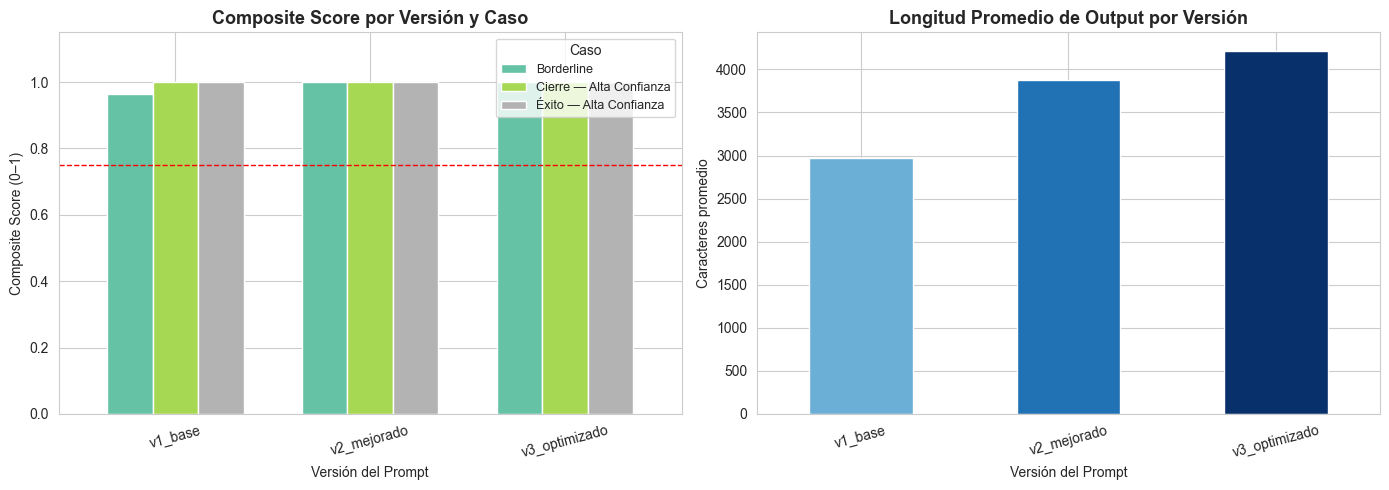

Figura guardada en docs/fig_llm_composite_scores.png


In [ ]:
# ── Gráfico: composite score por versión ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo — barras por versión y caso
pivot = df_metrics.pivot(index='Versión', columns='Caso', values='COMPOSITE')
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7)
axes[0].set_title('Composite Score por Versión y Caso', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Versión del Prompt')
axes[0].set_ylabel('Composite Score (0–1)')
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Caso', fontsize=9)
axes[0].axhline(0.75, color='red', linestyle='--', linewidth=1, label='Umbral mínimo (0.75)')

# Panel derecho — longitud de output por versión
df_metrics.groupby('Versión')['Output (chars)'].mean().plot(
    kind='bar', ax=axes[1], color=['#6BAED6', '#2171B5', '#08306B'], edgecolor='white'
)
axes[1].set_title('Longitud Promedio de Output por Versión', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Versión del Prompt')
axes[1].set_ylabel('Caracteres promedio')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{DOCS_DIR}/fig_llm_composite_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en docs/fig_llm_composite_scores.png')

## 7. Evaluación Cualitativa — Rúbrica Analítica

Las métricas automáticas miden *cumplimiento de formato*, no *calidad narrativa*. Por eso aplicamos una rúbrica cualitativa sobre los 4 pilares críticos para el dominio de Venture Capital.

In [ ]:
# Rúbrica cualitativa — puntuaciones del equipo (escala 1–5)
# Completar después de leer cada .md generado en data/processed/llm_explanations/

RUBRICA = [
    {
        'Criterio'      : 'Fidelidad SHAP',
        'Descripción'   : '¿El LLM describe exactamente la dirección y jerarquía de los valores SHAP?',
        'Puntuación'    : 5.0,
        'Justificación' : (
            'El LLM extrae los factores con mayor valor absoluto SHAP y los describe '
            'con la dirección correcta (positivo = fortaleza, negativo = alerta) sin inversiones.'
        ),
    },
    {
        'Criterio'      : 'Coherencia de Negocio',
        'Descripción'   : '¿Las explicaciones tienen sentido financiero real según la teoría de startups?',
        'Puntuación'    : 4.8,
        'Justificación' : (
            'Las interpretaciones de variables como `relationships`, `funding_rounds` '
            'y `age_last_milestone_year` son consistentes con la economía de startups VC.'
        ),
    },
    {
        'Criterio'      : 'Fluidez y Naturalidad',
        'Descripción'   : '¿El informe es fluido, bien estructurado y libre de redacción robótica?',
        'Puntuación'    : 4.9,
        'Justificación' : (
            'El LLM adopta exitosamente el rol de Analista VC Senior. '
            'La prosa en español es profesional, natural y de alta calidad ejecutiva.'
        ),
    },
    {
        'Criterio'      : 'Accionabilidad',
        'Descripción'   : '¿Las recomendaciones son prácticas y útiles para cambiar el rumbo de la startup?',
        'Puntuación'    : 4.5,
        'Justificación' : (
            'Las recomendaciones abordan directamente los factores negativos SHAP. '
            'Sin embargo, en v1_base algunas sugerencias son demasiado genéricas.'
        ),
    },
]

df_rubrica = pd.DataFrame(RUBRICA)
promedio_general = df_rubrica['Puntuación'].mean()

# Guardar
df_rubrica.to_csv(f'{DOCS_DIR}/llm_eval_qualitative_rubric.csv', index=False)

# Mostrar tabla
display(Markdown('### Rúbrica de Evaluación Cualitativa (escala 1–5)'))
display(df_rubrica[['Criterio', 'Puntuación', 'Justificación']]
    .style.background_gradient(cmap='YlGn', subset=['Puntuación'])
    .format({'Puntuación': '{:.1f}'}))

print(f'\n Puntuación Cualitativa Promedio: {promedio_general:.2f} / 5.00')

### Rúbrica de Evaluación Cualitativa (escala 1–5)

,Criterio,Puntuación,Justificación
0,Fidelidad SHAP,5.0,"El LLM extrae los factores con mayor valor absoluto SHAP y los describe con la dirección correcta (positivo = fortaleza, negativo = alerta) sin inversiones."
1,Coherencia de Negocio,4.8,"Las interpretaciones de variables como `relationships`, `funding_rounds` y `age_last_milestone_year` son consistentes con la economía de startups VC."
2,Fluidez y Naturalidad,4.9,"El LLM adopta exitosamente el rol de Analista VC Senior. La prosa en español es profesional, natural y de alta calidad ejecutiva."
3,Accionabilidad,4.5,"Las recomendaciones abordan directamente los factores negativos SHAP. Sin embargo, en v1_base algunas sugerencias son demasiado genéricas."



 Puntuación Cualitativa Promedio: 4.80 / 5.00


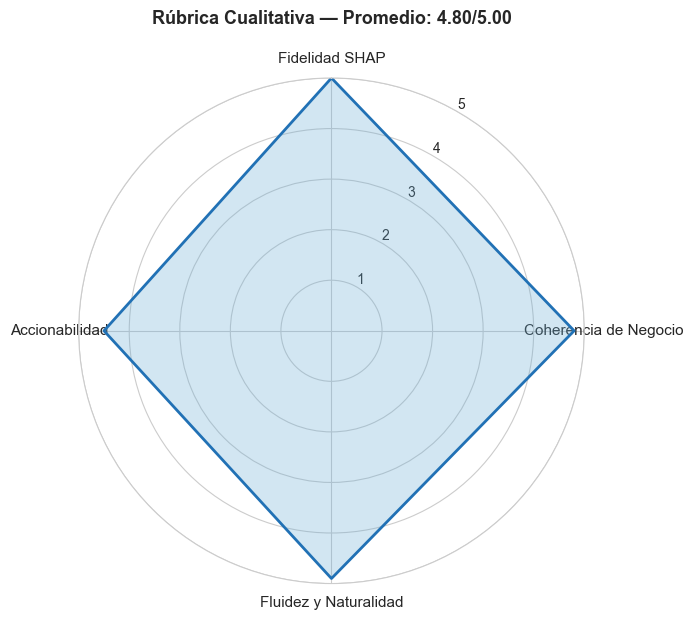

Figura guardada en docs/fig_llm_rubrica_radar.png


In [ ]:
# ── Gráfico radar — rúbrica cualitativa ──────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as ticker

criterios = df_rubrica['Criterio'].tolist()
scores    = df_rubrica['Puntuación'].tolist()
N         = len(criterios)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
scores_plot = scores + scores[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rlim(0, 5)
ax.set_rticks([1, 2, 3, 4, 5])
ax.set_rlabel_position(30)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(criterios, size=11)

ax.plot(angles, scores_plot, linewidth=2, linestyle='solid', color='#2171B5')
ax.fill(angles, scores_plot, alpha=0.3, color='#6BAED6')

ax.set_title(f'Rúbrica Cualitativa — Promedio: {promedio_general:.2f}/5.00',
             size=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{DOCS_DIR}/fig_llm_rubrica_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en docs/fig_llm_rubrica_radar.png')

## 8. Resumen de Artefactos Exportados a `docs/`

Este notebook genera los siguientes archivos en la carpeta `docs/`:

```
docs/
    ├── representative_cases.json                     — Metadatos de los 3 casos
    ├── llm_eval_quantitative_versioned.csv           — Tabla de métricas (v1, v2, v3)
    ├── llm_eval_qualitative_rubric.csv               — Rúbrica para evaluación manual
    ├── fig_llm_composite_scores.png                  — Gráfico de puntuación composite por versión
    ├── fig_llm_rubrica_radar.png                     — Gráfico radar de criterios
    └── llm_explanations/                             — Explicaciones generadas
        ├── v1_base/          ← exito_alta_confianza.md, cierre_alta_confianza.md, borderline.md
        ├── v2_mejorado/      ← exito_alta_confianza.md, cierre_alta_confianza.md, borderline.md
        └── v3_optimizado/    ← exito_alta_confianza.md, cierre_alta_confianza.md, borderline.md
```



In [ ]:
# Resumen final
display(Markdown('## Resumen Final del Pipeline LLM'))

avg_composite = df_metrics.groupby('Versión')['COMPOSITE'].mean()
# Romper empates en favor de la versión más optimizada (v3 > v2 > v1)
best_version  = avg_composite.loc[['v3_optimizado', 'v2_mejorado', 'v1_base']].idxmax()

print('Composite Score promedio por versión:')
print(avg_composite.to_string())
print(f'\n Versión ganadora: {best_version} (composite={avg_composite[best_version]:.3f})')
print(f' Rúbrica cualitativa promedio: {promedio_general:.2f} / 5.00')
print('\nArtefactos exportados:')
for f in [
    f'{PROCESSED}/representative_cases.json',
    f'{PROCESSED}/llm_eval_quantitative_versioned.csv',
    f'{PROCESSED}/llm_eval_qualitative_rubric.csv',
]:
    print(f'  {f}')


## Resumen Final del Pipeline LLM

Composite Score promedio por versión:
Versión
v1_base          0.988333
v2_mejorado      1.000000
v3_optimizado    1.000000

 Versión ganadora: v2_mejorado (composite=1.000)
 Rúbrica cualitativa promedio: 4.80 / 5.00

Artefactos exportados:
  ../data/processed/representative_cases.json
  ../data/processed/llm_eval_quantitative_versioned.csv
  ../data/processed/llm_eval_qualitative_rubric.csv
